## Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.exceptions import InconsistentVersionWarning
from flask import Flask, jsonify, request

ModuleNotFoundError: No module named 'pandas'

## Carga de Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Data Science + IA UDD/Modulo 7/Proyecto 7/Your Career Aspirations of GenZ.csv')
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Your Current Country.  Your Current Zip Code / Pin Code Your Gender  \
0                 India                            273005        Male   
1                 India                            851129        Male   
2                 India                            123106      Female   
3                 India                            834003        Male   
4                 India                            301019      Female   

  Which of the below factors influence the most about your career aspirations ?  \
0       People who have changed the world for better                              
1       People who have changed the world for better                              
2                         Social Media like LinkedIn                              
3      People from my circle, but not family members                              
4             Inf

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 15 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                    --------------  ----- 
 0   Your Current Country.                                                                                                     235 non-null    object
 1   Your Current Zip Code / Pin Code                                                                                          235 non-null    int64 
 2   Your Gender                                                                                                               235 non-null    object
 3   Which of the below factors influence the most about your career aspirations ?                                             235 non-null    ob

##EDA

In [ ]:
df.columns.tolist()

['Your Current Country.',
 'Your Current Zip Code / Pin Code',
 'Your Gender',
 'Which of the below factors influence the most about your career aspirations ?',
 'Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it.',
 'How likely is that you will work for one employer for 3 years or more ?',
 'Would you work for a company whose mission is not clearly defined and publicly posted.',
 'How likely would you work for a company whose mission is misaligned with their public actions or even their product ?',
 'How likely would you work for a company whose mission is not bringing social impact ?',
 'What is the most preferred working environment for you.',
 'Which of the below Employers would you work with.',
 'Which type of learning environment that you are most likely to work in ?',
 'Which of the below careers looks close to your Aspirational job ?',
 'What type of Manager would you work without looking into your watch ?',


In [ ]:
# Mapeo para renombrar las columnas
new_column_names = {
    'Your Current Country.': 'country',
    'Your Current Zip Code / Pin Code': 'zip_code',
    'Your Gender': 'gender',
    'Which of the below factors influence the most about your career aspirations ?': 'influence_factor',
    'Would you definitely pursue a Higher Education / Post Graduation outside of India ? If only you have to self sponsor it.': 'higher_ed_self_sponsor',
    'How likely is that you will work for one employer for 3 years or more ?': 'work_3_years_plus',
    'Would you work for a company whose mission is not clearly defined and publicly posted.': 'undefined_mission',
    'How likely would you work for a company whose mission is misaligned with their public actions or even their product ?': 'misaligned_mission',
    'How likely would you work for a company whose mission is not bringing social impact ?': 'no_social_impact_likeli', # Numerica
    'What is the most preferred working environment for you.': 'preferred_work_env',
    'Which of the below Employers would you work with.': 'employer_preference',
    'Which type of learning environment that you are most likely to work in ?': 'learning_env',
    'Which of the below careers looks close to your Aspirational job ?': 'aspirational_job', # TARGET (Y)
    'What type of Manager would you work without looking into your watch ?': 'manager_style',
    'Which of the following setup you would like to work ?': 'team_setup'
}

df.rename(columns=new_column_names, inplace=True)

print("--- DataFrame con Nombres Limpios ---")
print(df.head())

--- DataFrame con Nombres Limpios ---
  country  zip_code  gender                               influence_factor  \
0   India    273005    Male   People who have changed the world for better   
1   India    851129    Male   People who have changed the world for better   
2   India    123106  Female                     Social Media like LinkedIn   
3   India    834003    Male  People from my circle, but not family members   
4   India    301019  Female         Influencers who had successful careers   

                          higher_ed_self_sponsor  \
0                   Yes, I will earn and do that   
1  No, But if someone could bare the cost I will   
2                   Yes, I will earn and do that   
3  No, But if someone could bare the cost I will   
4  No, But if someone could bare the cost I will   

                                   work_3_years_plus undefined_mission  \
0  This will be hard to do, but if it is the righ...                No   
1  This will be hard to do, but 

In [ ]:
# Revisar el target y variables clave
print("\n--- Conteo de Target (Aspiracion Original) ---")
print(df['aspirational_job'].value_counts())
print(f"Numero de clases unicas en el target: {df['aspirational_job'].nunique()}")

print("\n--- Conteo de Variable 'country' ---")
print(df['country'].value_counts())


--- Conteo de Target (Aspiracion Original) ---
aspirational_job
Business Operations in any organization, Manage and drive End-to-End Projects or Products, Look deeply into Data and generate insights        12
Business Operations in any organization, Manage and drive End-to-End Projects or Products, Build and develop a Team                           11
Business Operations in any organization, Build and develop a Team, Look deeply into Data and generate insights                                 9
Design and Creative strategy in any company, Teaching in any of the institutes/online or Offline, Business Operations in any organization      9
Design and Creative strategy in any company, Manage and drive End-to-End Projects or Products, Look deeply into Data and generate insights     8
                                                                                                                                              ..
Teaching in any of the institutes/online or Offline, Business Ope

In [ ]:
# Mapeo de valores complejos a categorias principales
def simplify_aspirations(job):
    job = str(job).lower()
    # 1. Negocios, Operaciones y Ventas
    if 'business operations' in job or 'sales' in job or 'marketing' in job:
        return 'Business/Ops/Sales'
    # 2. Gestion (Proyectos y Productos)
    elif 'manage and drive' in job or 'project' in job or 'product' in job:
        return 'Project/Product Management'
    # 3. Educacion
    elif 'teaching' in job or 'training' in job or 'professor' in job:
        return 'Academia/Training'
    # 4. Tecnologia, Datos y Desarrollo de Software
    elif 'coding' in job or 'development' in job or 'data scientist' in job or 'ai/ml' in job or 'design and develop amazing software' in job:
        return 'Technology/Data/SW Dev'
    # 5. Todo lo demas (Creativo, Freelancer, Contenido, etc.)
    else:
        return 'Creative/Other'

# Aplicar la simplificacion al target
df['simplified_aspirations'] = df['aspirational_job'].apply(simplify_aspirations)

print("\n--- Conteo del Target Simplificado (Y) ---")
print(df['simplified_aspirations'].value_counts())


--- Conteo del Target Simplificado (Y) ---
simplified_aspirations
Business/Ops/Sales            95
Project/Product Management    46
Academia/Training             41
Creative/Other                27
Technology/Data/SW Dev        26
Name: count, dtype: int64


In [ ]:
# 1. Definir X (features) y Y (target simplificado)
# Excluir: 'country' (poca varianza), 'zip_code' (no informativo), y los targets originales
X = df.drop(['country', 'zip_code', 'aspirational_job', 'simplified_aspirations'], axis=1)
Y = df['simplified_aspirations']

# 2. Codificacion One-Hot de X
# drop_first=True evita la multicolinealidad
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
# 3. Escalado de la caracteristica numerica
# Estandarizacion (media=0, desviacion estandar=1)
scaler = StandardScaler()
X_encoded['no_social_impact_likeli'] = scaler.fit_transform(
    X_encoded[['no_social_impact_likeli']]
)

# 4. Separar en conjuntos de entrenamiento y prueba
# Usamos stratify=Y para mantener la proporcion de las 5 clases en train y test.
X_train, X_test, Y_train, Y_test = train_test_split(
    X_encoded, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f"Numero total de features codificadas: {X_encoded.shape[1]}")
print(f"Dimensiones de entrenamiento: {X_train.shape}")

Numero total de features codificadas: 49
Dimensiones de entrenamiento: (188, 49)


##Entrenamiento del Modelo

In [ ]:
# 1. Inicializar y entrenar el modelo Random Forest
# class_weight='balanced' ajusta automaticamente el peso de las muestras
model_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_base.fit(X_train, Y_train)

# 2. Predicciones de prueba (Requisito de Actividad 2)
Y_pred_base = model_base.predict(X_test)
accuracy_base = accuracy_score(Y_test, Y_pred_base)

print("="*60)
print(f"Precisión (Accuracy) del modelo BASE: {accuracy_base:.4f}")
# Necesitamos que sea > 0.60
print("\nReporte de Clasificación (Baseline):\n", classification_report(Y_test, Y_pred_base, zero_division=0))
print("="*60)

# 3. Guardar el modelo BASE (antes del tuning) y las features (necesario para la API)
joblib.dump(model_base, 'aspirations_model_base.pkl')
feature_names = X_encoded.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

Precisión (Accuracy) del modelo BASE: 0.4043

Reporte de Clasificación (Baseline):
                             precision    recall  f1-score   support

         Academia/Training       0.25      0.12      0.17         8
        Business/Ops/Sales       0.45      0.79      0.58        19
            Creative/Other       0.00      0.00      0.00         6
Project/Product Management       0.33      0.33      0.33         9
    Technology/Data/SW Dev       0.00      0.00      0.00         5

                  accuracy                           0.40        47
                 macro avg       0.21      0.25      0.22        47
              weighted avg       0.29      0.40      0.33        47



## Tuning y Ensambles

In [ ]:
print("\nIniciando la busqueda de hiperparametros (Tuning)...")

# 1. Definir el espacio de busqueda
param_dist = {
    'n_estimators': [150, 250, 400], # Numero de arboles
    'max_depth': [10, 20, None], # Profundidad maxima del arbol
    'min_samples_split': [5, 10], # Minimo de muestras para dividir un nodo
    'min_samples_leaf': [2, 4], # Minimo de muestras en el nodo hoja
    'class_weight': ['balanced'] # Usamos 'balanced' para mitigar el desequilibrio
}

# 2. Inicializar RandomizedSearchCV
# Probaremos 30 combinaciones (n_iter=30) con validacion cruzada (cv=5)
rf_tuned = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

# 3. Entrenar la busqueda
rf_tuned.fit(X_train, Y_train)
best_rf_model = rf_tuned.best_estimator_

# 4. Prediccion y Metricas del modelo ajustado
Y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(Y_test, Y_pred_tuned)

print("\n" + "="*60)
print("RESULTADOS DEL MODELO AJUSTADO (TUNING)")
print(f"Mejor score de CV (Validacion Cruzada): {rf_tuned.best_score_:.4f}")
print("Mejores Hiperparametros:", rf_tuned.best_params_)
print("="*60)
print(f"Precisión (Accuracy) del modelo AJUSTADO en el set de prueba: {accuracy_tuned:.4f}")
print("\nReporte de Clasificacion Final:\n", classification_report(Y_test, Y_pred_tuned, zero_division=0))

# 5. Guardar el modelo final y las features
joblib.dump(best_rf_model, 'aspirations_classifier_final.pkl')
# Las features ya fueron guardadas en el paso anterior, pero las mantenemos
# feature_names = X_encoded.columns.tolist()
# with open('feature_names.json', 'w') as f:
#     json.dump(feature_names, f)


Iniciando la busqueda de hiperparametros (Tuning)...

RESULTADOS DEL MODELO AJUSTADO (TUNING)
Mejor score de CV (Validacion Cruzada): 0.3189
Mejores Hiperparametros: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'class_weight': 'balanced'}
Precisión (Accuracy) del modelo AJUSTADO en el set de prueba: 0.2979

Reporte de Clasificacion Final:
                             precision    recall  f1-score   support

         Academia/Training       0.14      0.25      0.18         8
        Business/Ops/Sales       0.43      0.47      0.45        19
            Creative/Other       0.00      0.00      0.00         6
Project/Product Management       0.33      0.33      0.33         9
    Technology/Data/SW Dev       0.00      0.00      0.00         5

                  accuracy                           0.30        47
                 macro avg       0.18      0.21      0.19        47
              weighted avg       0.26      0.30      0.28        47



['aspirations_classifier_final.pkl']

## Graficos Personalizados

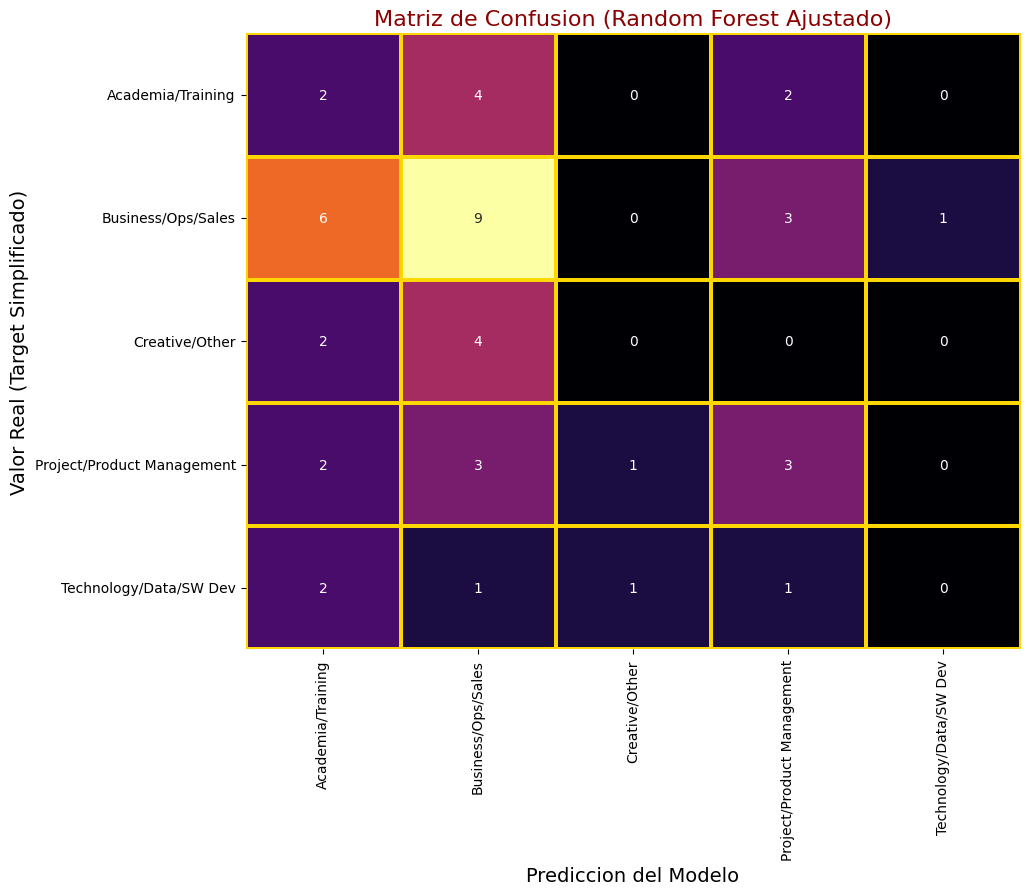

In [ ]:
# Recrear los labels de clase (basados en el Y_test)
class_labels = np.unique(Y_test)

# Generar la Matriz de Confusion
cm = confusion_matrix(Y_test, Y_pred_tuned)

plt.figure(figsize=(10, 8))
# Personalizacion: Usamos un colormap llamativo ('inferno') y mejoramos bordes
sns.heatmap(cm, annot=True, fmt='d', cmap='inferno',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=1.5, linecolor='gold', cbar=False)
plt.title('Matriz de Confusion (Random Forest Ajustado)', fontsize=16, color='darkred')
plt.xlabel('Prediccion del Modelo', fontsize=14)
plt.ylabel('Valor Real (Target Simplificado)', fontsize=14)
plt.show()

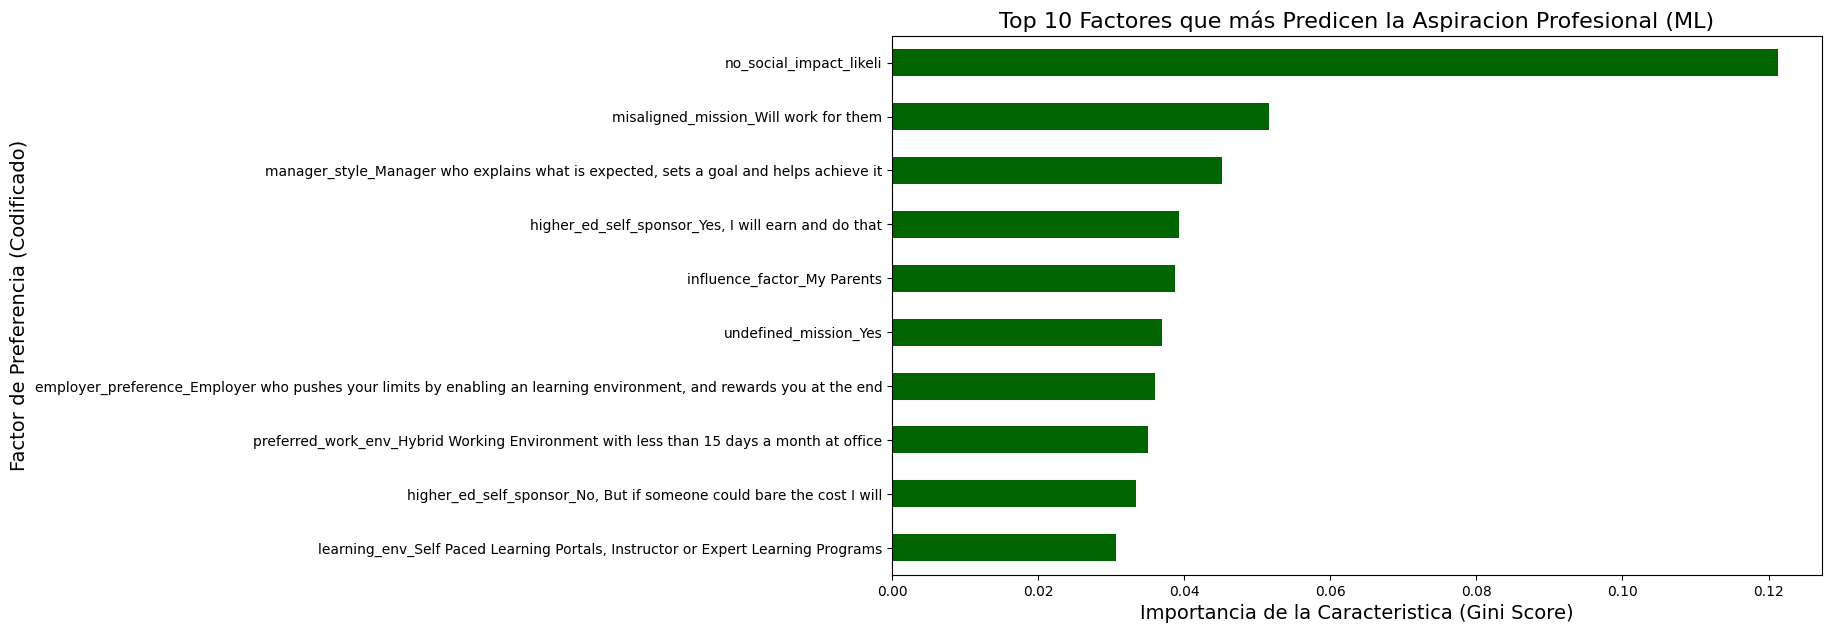

In [ ]:
# 1. Obtener las importancias de las caracteristicas del mejor modelo
feature_importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)

# 2. Seleccionar el top 10
top_10_features = feature_importances.nlargest(10)

plt.figure(figsize=(12, 7))
# Personalizacion: Usamos un color solido y ordenamos para mejor lectura
top_10_features.sort_values().plot(kind='barh', color='#006400') # Dark Green
plt.title('Top 10 Factores que más Predicen la Aspiracion Profesional (ML)', fontsize=16)
plt.xlabel('Importancia de la Caracteristica (Gini Score)', fontsize=14)
plt.ylabel('Factor de Preferencia (Codificado)', fontsize=14)
plt.show()